# Predizione del rischio di salute del figlio dalle caratteristiche dei genitori

**Programmazione di Applicazioni Data Intensive**

In questo progetto viene analizzato il dataset `parental_genetics_child_traits.csv`, che contiene informazioni anagrafiche, fisiche e genetiche dei genitori e alcune caratteristiche previste del figlio.  
L'obiettivo è costruire e confrontare modelli di **classificazione multiclasse** capaci di predire la variabile `Predicted_Health_Risk`, cioè il livello di rischio di salute previsto per il figlio.

Le classi possibili sono:

- `Low`
- `Moderate`
- `High`

Il progetto segue i passaggi richiesti dalle linee guida: descrizione del dataset, analisi esplorativa, preparazione dei dati, addestramento di più modelli, valutazione delle performance e ricerca degli iperparametri.

## 1. Importazione delle librerie

Importiamo le librerie principali per l'analisi dei dati, la visualizzazione grafica e la costruzione dei modelli di machine learning.

In [3]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)


Matplotlib is building the font cache; this may take a moment.


## 2. Caricamento del dataset

Il dataset è fornito in formato CSV. La prima operazione consiste nel caricarlo in un DataFrame Pandas e osservarne le prime righe.

In [4]:
dataset = pd.read_csv("parental_genetics_child_traits.csv")
dataset.head()

,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


## 3. Descrizione generale del dataset

Controlliamo dimensione del dataset, tipi delle variabili e presenza di valori mancanti.

In [5]:
print("Numero di righe e colonne:", dataset.shape)
dataset.info()

Numero di righe e colonne: (7000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Family_ID                    7000 non-null   object 
 1   Father_Age                   7000 non-null   int64  
 2   Mother_Age                   7000 non-null   int64  
 3   Father_Height_cm             7000 non-null   float64
 4   Mother_Height_cm             7000 non-null   float64
 5   Father_Blood_Group           7000 non-null   object 
 6   Mother_Blood_Group           7000 non-null   object 
 7   Father_Eye_Color             7000 non-null   object 
 8   Mother_Eye_Color             7000 non-null   object 
 9   Father_Hair_Color            7000 non-null   object 
 10  Mother_Hair_Color            7000 non-null   object 
 11  Father_Skin_Tone             7000 non-null   object 
 12  Mother_Skin_Tone             7000 non-

In [7]:
missing_values = dataset.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

Il dataset contiene 7000 osservazioni e 18 colonne.  
La variabile `Family_ID` è un semplice identificatore della famiglia e non contiene informazione utile per la predizione, quindi verrà eliminata.

La colonna `Family_Disease_History` contiene valori mancanti. In questo caso l'assenza di un valore può essere interpretata come assenza di una storia familiare specifica, quindi verrà sostituita con la categoria `None`.

In [6]:
dataset = dataset.drop(columns=["Family_ID"])
dataset["Family_Disease_History"] = dataset["Family_Disease_History"].fillna("None")

dataset.isna().sum().sum()

np.int64(0)

## 4. Variabili del dataset

Le variabili possono essere suddivise in tre gruppi principali:

1. **Caratteristiche dei genitori**, come età, altezza, gruppo sanguigno, colore degli occhi, colore dei capelli e carnagione.
2. **Informazioni familiari**, come la storia familiare di malattie.
3. **Caratteristiche previste del figlio**, come altezza prevista, gruppo sanguigno previsto e rischio di salute previsto.

Per evitare un problema di *data leakage*, non useremo `Predicted_Child_Height_cm` e `Predicted_Child_Blood_Group` come variabili predittive. Queste colonne sono già caratteristiche previste del figlio e potrebbero rendere il modello meno realistico.  
Il modello userà quindi solo informazioni relative ai genitori e al genere del figlio.

In [8]:
dataset.describe()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,37.650286,34.035857,173.970257,161.084257,167.595814
std,10.323333,9.447972,6.922160,5.971471,8.816473
min,20.000000,18.000000,155.000000,145.000000,140.600000
25%,29.000000,26.000000,169.200000,157.000000,161.100000
50%,38.000000,34.000000,174.000000,161.100000,167.700000
75%,47.000000,42.000000,178.700000,165.200000,174.200000
max,55.000000,50.000000,197.900000,185.000000,198.500000


## 5. Analisi della variabile target

Analizziamo la distribuzione della variabile `Predicted_Health_Risk`. Questo passaggio è importante per capire se le classi sono bilanciate o se una classe è molto più frequente delle altre.

In [7]:
target = "Predicted_Health_Risk"

target_counts = dataset[target].value_counts()
target_percentages = dataset[target].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    "conteggio": target_counts,
    "percentuale": target_percentages
})

,conteggio,percentuale
Predicted_Health_Risk,,
Moderate,3832,54.74
High,1723,24.61
Low,1445,20.64


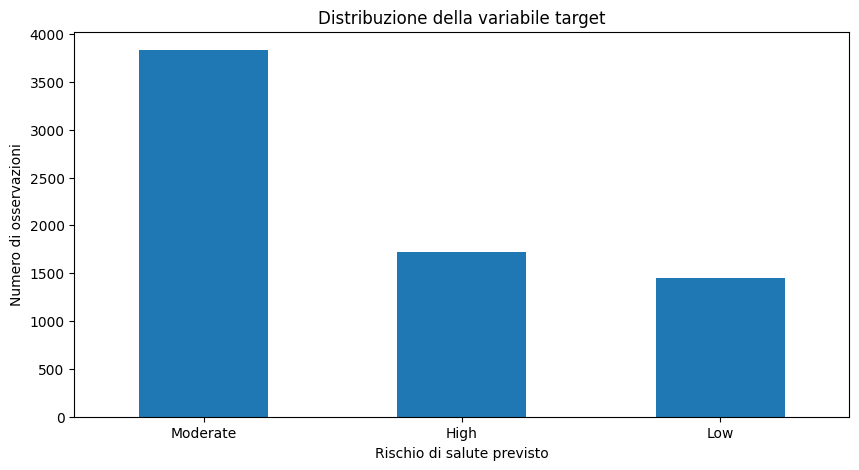

In [8]:
target_counts.plot(kind="bar")
plt.title("Distribuzione della variabile target")
plt.xlabel("Rischio di salute previsto")
plt.ylabel("Numero di osservazioni")
plt.xticks(rotation=0)
plt.show()

La classe più frequente è `Moderate`, mentre `Low` e `High` sono meno rappresentate. Il dataset è quindi moderatamente sbilanciato.  
Per questo motivo, oltre all'accuracy, useremo anche precision, recall e soprattutto F1-score macro, che valuta le classi dando lo stesso peso a ciascuna.

## 6. Analisi esplorativa delle variabili numeriche

Le variabili numeriche principali sono età e altezza dei genitori, oltre alle caratteristiche previste del figlio. Anche se alcune di queste ultime non saranno usate come feature predittive, sono utili per comprendere meglio il dataset.

In [9]:
numeric_columns = dataset.select_dtypes(include=np.number).columns.tolist()
numeric_columns

['Father_Age',
 'Mother_Age',
 'Father_Height_cm',
 'Mother_Height_cm',
 'Predicted_Child_Height_cm']

In [10]:
dataset[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Father_Age,7000.0,37.650286,10.323333,20.0,29.0,38.0,47.0,55.0
Mother_Age,7000.0,34.035857,9.447972,18.0,26.0,34.0,42.0,50.0
Father_Height_cm,7000.0,173.970257,6.922160,155.0,169.2,174.0,178.7,197.9
Mother_Height_cm,7000.0,161.084257,5.971471,145.0,157.0,161.1,165.2,185.0
Predicted_Child_Height_cm,7000.0,167.595814,8.816473,140.6,161.1,167.7,174.2,198.5


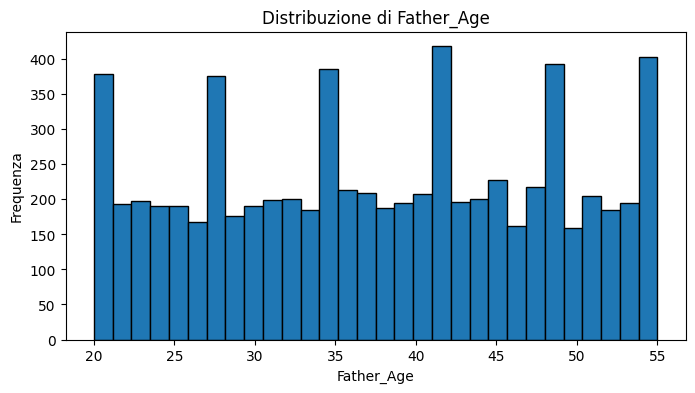

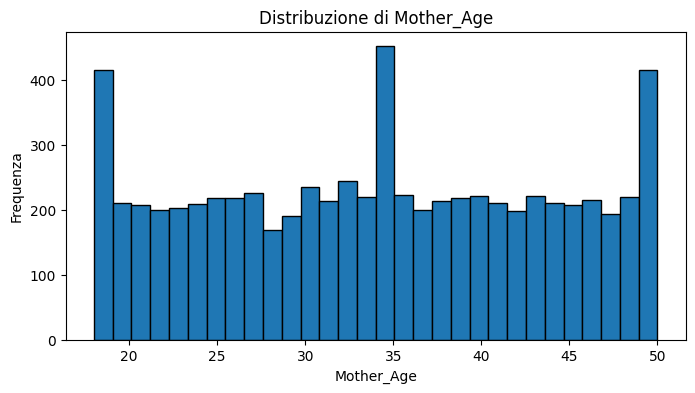

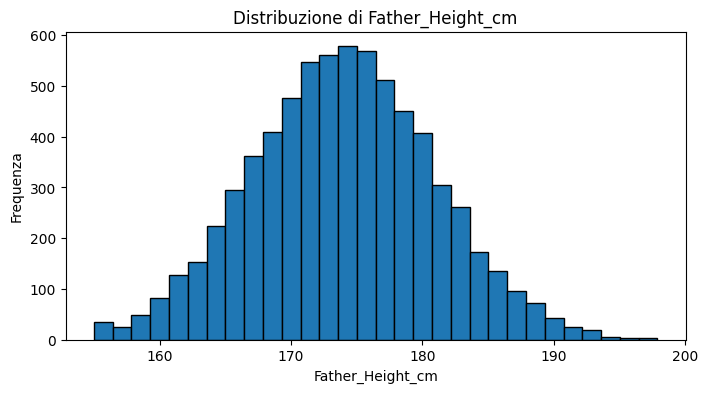

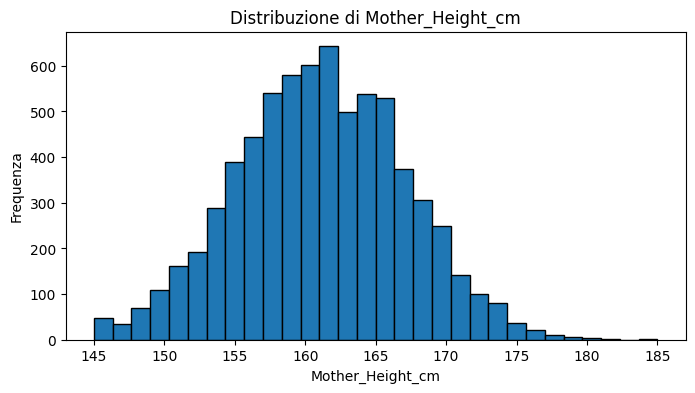

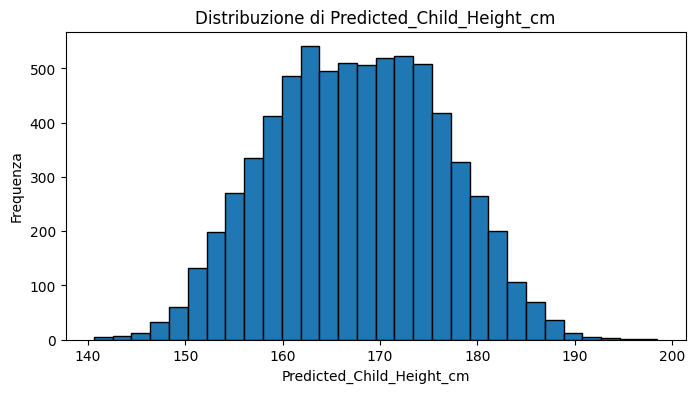

In [11]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    dataset[col].plot(kind="hist", bins=30, edgecolor="black")
    plt.title(f"Distribuzione di {col}")
    plt.xlabel(col)
    plt.ylabel("Frequenza")
    plt.show()

Le distribuzioni di età e altezza risultano abbastanza regolari. Le altezze dei genitori e l'altezza prevista del figlio sono variabili continue, mentre le età assumono valori interi all'interno di un intervallo realistico.

## 7. Relazioni tra variabili numeriche e target

Osserviamo se l'età e l'altezza dei genitori cambiano in modo evidente al variare del rischio di salute previsto.

<Figure size 800x400 with 0 Axes>

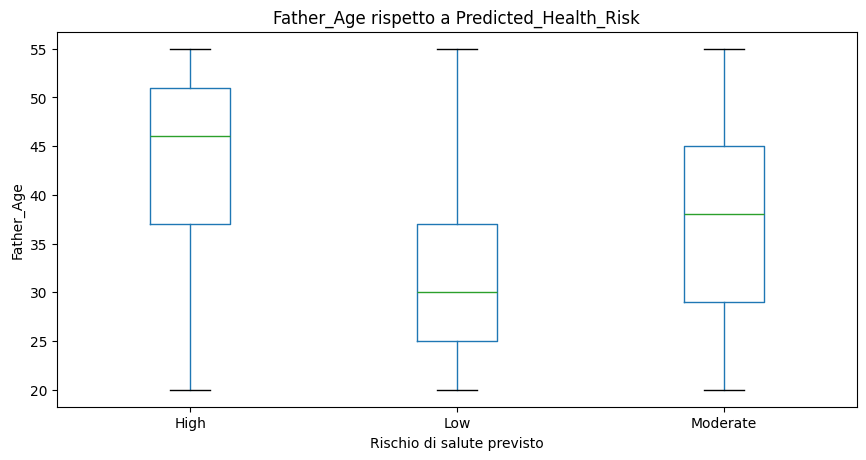

<Figure size 800x400 with 0 Axes>

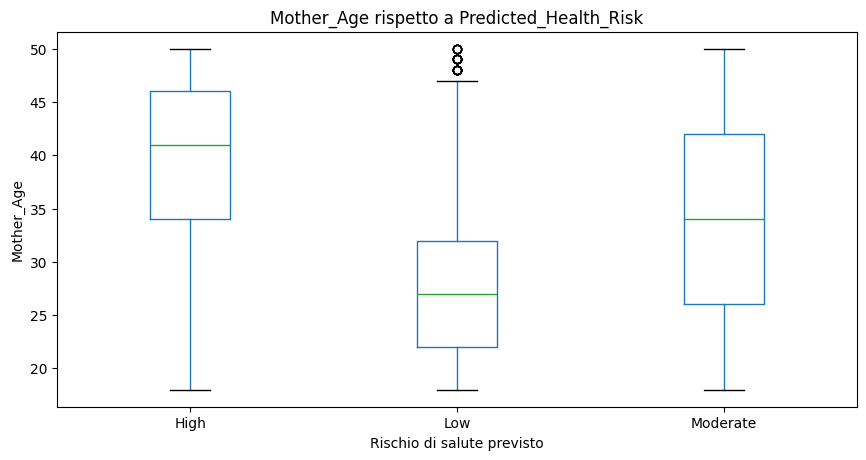

<Figure size 800x400 with 0 Axes>

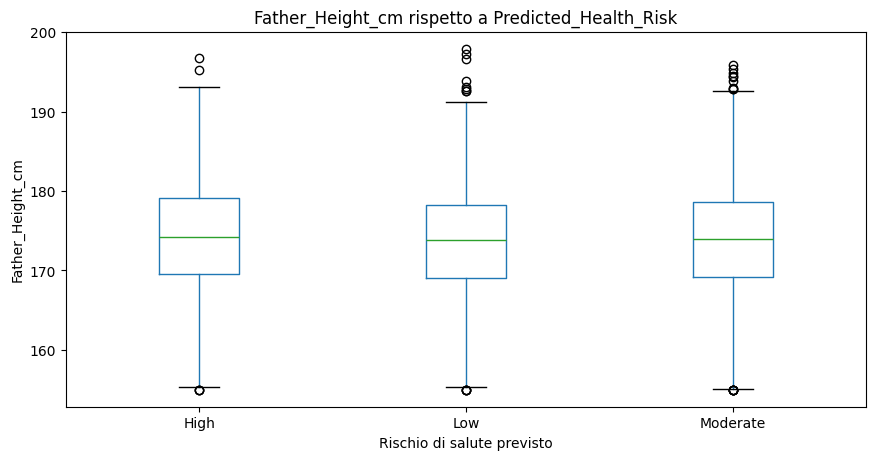

<Figure size 800x400 with 0 Axes>

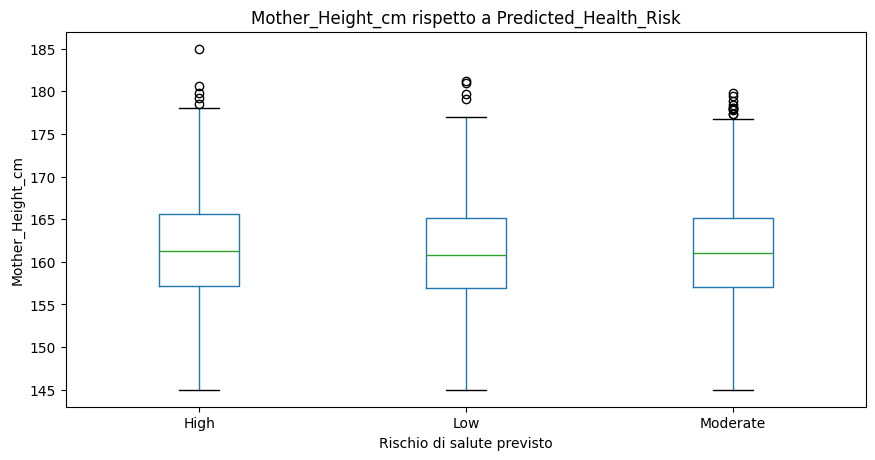

In [12]:
predictive_numeric_columns = [
    "Father_Age",
    "Mother_Age",
    "Father_Height_cm",
    "Mother_Height_cm"
]

for col in predictive_numeric_columns:
    plt.figure(figsize=(8, 4))
    dataset.boxplot(column=col, by=target, grid=False)
    plt.title(f"{col} rispetto a {target}")
    plt.suptitle("")
    plt.xlabel("Rischio di salute previsto")
    plt.ylabel(col)
    plt.show()

Dai boxplot non emerge una separazione molto netta delle classi usando solo età e altezza. Questo suggerisce che le variabili categoriche, in particolare la storia familiare di malattie, potrebbero avere un ruolo importante nella predizione.

## 8. Analisi delle variabili categoriche

Analizziamo le frequenze delle principali variabili categoriche.

In [13]:
categorical_columns = dataset.select_dtypes(exclude=np.number).columns.tolist()
categorical_columns.remove(target)

for col in categorical_columns:
    print()
    print(col)
    display(dataset[col].value_counts().head(10))


Father_Blood_Group


Father_Blood_Group
A+     2130
B+     1730
O+     1709
A-      465
B-      355
AB+     339
O-      212
AB-      60
Name: count, dtype: int64


Mother_Blood_Group


Mother_Blood_Group
A+     2074
O+     1757
B+     1753
A-      422
B-      366
AB+     341
O-      228
AB-      59
Name: count, dtype: int64


Father_Eye_Color


...

Family_Disease_History
None             2461
Diabetes         1286
Hypertension     1249
Heart Disease     809
Asthma            679
Multiple          516
Name: count, dtype: int64


Child_Gender


Child_Gender
Male      3542
Female    3458
Name: count, dtype: int64


Predicted_Child_Blood_Group


Predicted_Child_Blood_Group
A+     1750
B+     1350
AB+    1208
A-      838
B-      658
AB-     634
O+      383
O-      179
Name: count, dtype: int64

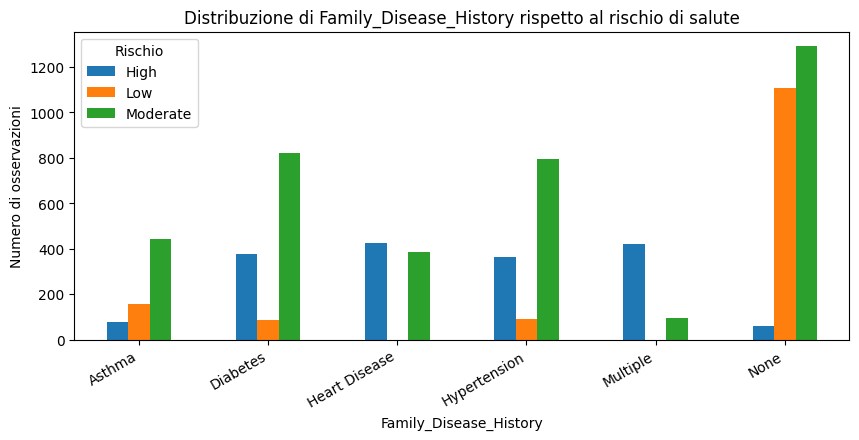

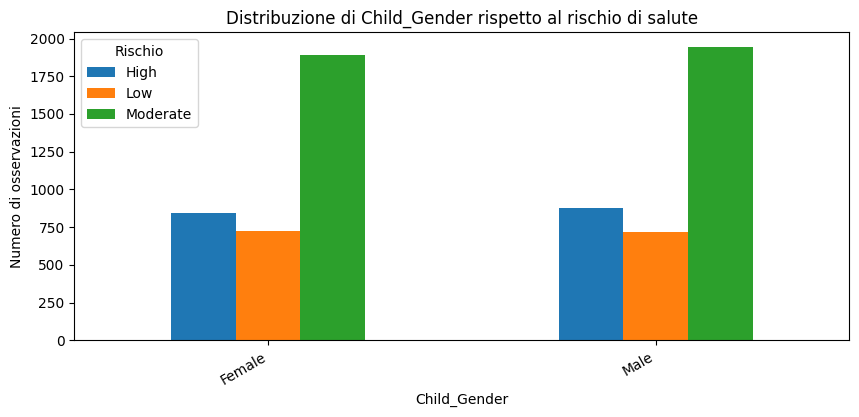

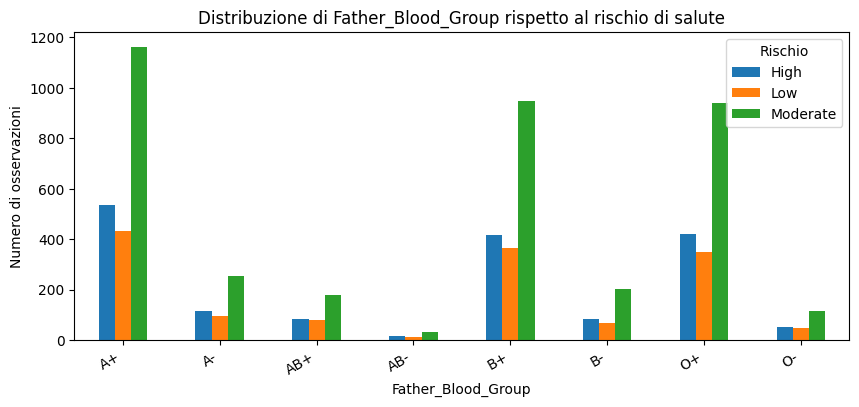

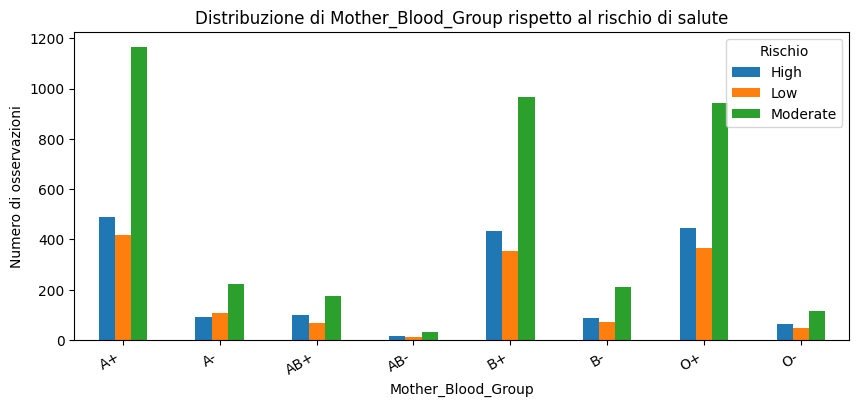

In [14]:
selected_categorical_columns = [
    "Family_Disease_History",
    "Child_Gender",
    "Father_Blood_Group",
    "Mother_Blood_Group"
]

for col in selected_categorical_columns:
    tab = pd.crosstab(dataset[col], dataset[target])
    tab.plot(kind="bar", figsize=(10, 4))
    plt.title(f"Distribuzione di {col} rispetto al rischio di salute")
    plt.xlabel(col)
    plt.ylabel("Numero di osservazioni")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Rischio")
    plt.show()

La variabile `Family_Disease_History` appare particolarmente informativa: alcune categorie di storia familiare sono associate con frequenze diverse delle classi di rischio. Questo è coerente con l'obiettivo del dataset, perché la presenza di patologie familiari dovrebbe influenzare il rischio previsto.

## 9. Matrice di correlazione

Calcoliamo la correlazione tra le variabili numeriche. La correlazione è calcolata solo sulle variabili numeriche, quindi non include direttamente le variabili categoriche.

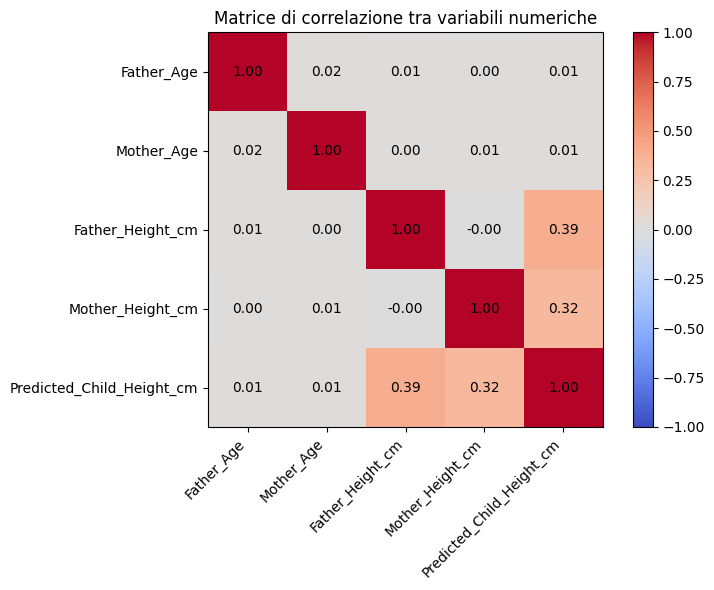

In [15]:
corr = dataset[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.title("Matrice di correlazione tra variabili numeriche")
plt.tight_layout()
plt.show()

La correlazione più intuitiva riguarda le altezze dei genitori e l'altezza prevista del figlio. Tuttavia, dato che l'altezza prevista del figlio non verrà usata come feature predittiva, il modello finale sarà costruito solo sulle informazioni disponibili prima della previsione del rischio.

## 10. Preparazione dei dati

Separiamo la variabile target dalle variabili predittive.  
Eliminiamo inoltre `Predicted_Child_Height_cm` e `Predicted_Child_Blood_Group` per evitare leakage.

In [16]:
features_to_remove = [
    "Predicted_Health_Risk",
    "Predicted_Child_Height_cm",
    "Predicted_Child_Blood_Group"
]

X = dataset.drop(columns=features_to_remove)
y = dataset[target]

print("Dimensioni X:", X.shape)
print("Dimensioni y:", y.shape)

Dimensioni X: (7000, 14)
Dimensioni y: (7000,)


In [17]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variabili numeriche:", numeric_features)
print("Variabili categoriche:", categorical_features)

Variabili numeriche: ['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm']
Variabili categoriche: ['Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History', 'Child_Gender']


Le variabili categoriche verranno trasformate tramite **one-hot encoding**.  
Le variabili numeriche verranno imputate con la mediana e, per i modelli sensibili alla scala come Logistic Regression e KNN, verranno anche standardizzate.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5250, 14)
Test set: (1750, 14)


In [19]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 11. Funzione di valutazione

Definiamo una funzione per addestrare ogni modello e calcolare le metriche principali:

- accuracy;
- precision macro;
- recall macro;
- F1-score macro.

In [20]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    }

## 12. Addestramento dei modelli

Confrontiamo diversi algoritmi di classificazione:

1. **Dummy Classifier**, usato come baseline;
2. **Logistic Regression**;
3. **Decision Tree Classifier**;
4. **Random Forest Classifier**;
5. **K-Nearest Neighbors**.

In [21]:
models = {
    "Dummy Classifier": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]),
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=80,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", KNeighborsClassifier(n_neighbors=15))
    ])
}

results = []

for name, model in models.items():
    results.append(evaluate_model(name, model, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)
results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
3,Random Forest,0.758857,0.787527,0.697681,0.729343
1,Logistic Regression,0.727429,0.711337,0.767746,0.728654
2,Decision Tree,0.717714,0.710217,0.693047,0.700962
4,KNN,0.678286,0.711612,0.591366,0.620317
0,Dummy Classifier,0.547429,0.182476,0.333333,0.235844


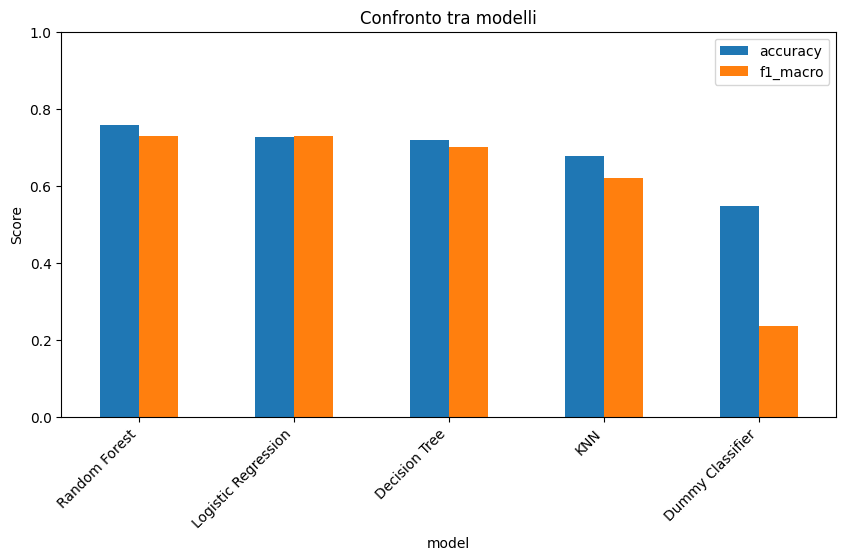

In [22]:
results_df.set_index("model")[["accuracy", "f1_macro"]].plot(kind="bar")
plt.title("Confronto tra modelli")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.show()

I modelli superano nettamente la baseline del Dummy Classifier.  
La Random Forest tende a ottenere buone performance complessive perché riesce a modellare relazioni non lineari e interazioni tra variabili categoriche e numeriche.

## 13. Report dettagliato del modello migliore iniziale

Osserviamo precision, recall e F1-score per ciascuna classe del modello migliore prima della ricerca degli iperparametri.

In [23]:
best_model_name = results_df.iloc[0]["model"]
best_initial_model = models[best_model_name]
best_initial_model.fit(X_train, y_train)
y_pred_initial = best_initial_model.predict(X_test)

print("Miglior modello iniziale:", best_model_name)
print(classification_report(y_test, y_pred_initial))

Miglior modello iniziale: Random Forest
              precision    recall  f1-score   support

        High       0.81      0.61      0.70       431
         Low       0.82      0.60      0.69       361
    Moderate       0.73      0.89      0.80       958

    accuracy                           0.76      1750
   macro avg       0.79      0.70      0.73      1750
weighted avg       0.77      0.76      0.75      1750



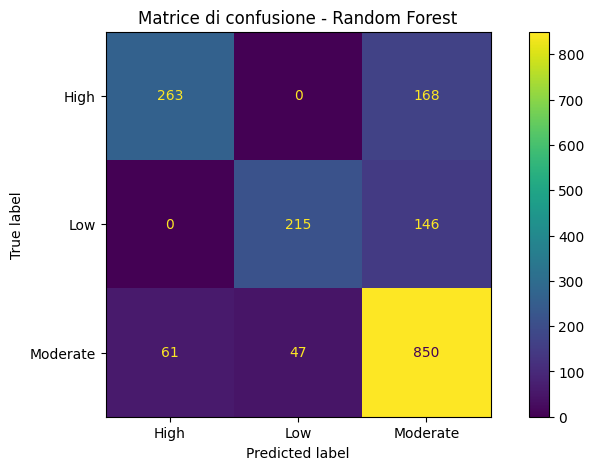

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_initial)
plt.title(f"Matrice di confusione - {best_model_name}")
plt.show()

La matrice di confusione consente di osservare quali classi vengono confuse più spesso. In generale, la classe `Moderate`, essendo la più frequente, è quella che il modello riconosce con maggiore facilità.

## 14. Ricerca degli iperparametri

Applichiamo una Grid Search su due modelli:

- Logistic Regression;
- Random Forest.

La metrica da massimizzare è `f1_macro`, perché considera in modo bilanciato tutte le classi.

In [25]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

In [26]:
logistic_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__solver": ["lbfgs"]
}

logistic_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    param_grid=logistic_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

logistic_search.fit(X_train, y_train)

print("Migliori parametri Logistic Regression:")
print(logistic_search.best_params_)
print("Miglior F1 macro in cross validation:", logistic_search.best_score_)

Migliori parametri Logistic Regression:
{'classifier__C': 1, 'classifier__solver': 'lbfgs'}
Miglior F1 macro in cross validation: 0.7165094473369957


In [27]:
forest_grid = {
    "classifier__n_estimators": [60],
    "classifier__max_depth": [None, 10],
    "classifier__min_samples_leaf": [1, 3],
    "classifier__max_features": ["sqrt"]
}

forest_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),
    param_grid=forest_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

forest_search.fit(X_train, y_train)

print("Migliori parametri Random Forest:")
print(forest_search.best_params_)
print("Miglior F1 macro in cross validation:", forest_search.best_score_)

Migliori parametri Random Forest:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 60}
Miglior F1 macro in cross validation: 0.7317542044064854


## 15. Valutazione dei modelli ottimizzati

Valutiamo sul test set i modelli ottenuti tramite Grid Search.

In [28]:
optimized_models = {
    "Logistic Regression ottimizzata": logistic_search.best_estimator_,
    "Random Forest ottimizzata": forest_search.best_estimator_
}

optimized_results = []
for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    optimized_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

optimized_results_df = pd.DataFrame(optimized_results).sort_values(by="f1_macro", ascending=False)
optimized_results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
1,Random Forest ottimizzata,0.747429,0.729659,0.766463,0.744014
0,Logistic Regression ottimizzata,0.727429,0.711337,0.767746,0.728654


In [29]:
final_results_df = pd.concat([results_df, optimized_results_df], ignore_index=True)
final_results_df.sort_values(by="f1_macro", ascending=False)

,model,accuracy,precision_macro,recall_macro,f1_macro
5,Random Forest ottimizzata,0.747429,0.729659,0.766463,0.744014
0,Random Forest,0.758857,0.787527,0.697681,0.729343
1,Logistic Regression,0.727429,0.711337,0.767746,0.728654
6,Logistic Regression ottimizzata,0.727429,0.711337,0.767746,0.728654
2,Decision Tree,0.717714,0.710217,0.693047,0.700962
3,KNN,0.678286,0.711612,0.591366,0.620317
4,Dummy Classifier,0.547429,0.182476,0.333333,0.235844


In [30]:
best_final_name = final_results_df.sort_values(by="f1_macro", ascending=False).iloc[0]["model"]

if best_final_name == "Logistic Regression ottimizzata":
    best_final_model = logistic_search.best_estimator_
elif best_final_name == "Random Forest ottimizzata":
    best_final_model = forest_search.best_estimator_
else:
    best_final_model = models[best_final_name]
    best_final_model.fit(X_train, y_train)

final_predictions = best_final_model.predict(X_test)

print("Miglior modello finale:", best_final_name)
print(classification_report(y_test, final_predictions))

Miglior modello finale: Random Forest ottimizzata
              precision    recall  f1-score   support

        High       0.73      0.80      0.77       431
         Low       0.65      0.79      0.71       361
    Moderate       0.81      0.71      0.75       958

    accuracy                           0.75      1750
   macro avg       0.73      0.77      0.74      1750
weighted avg       0.76      0.75      0.75      1750



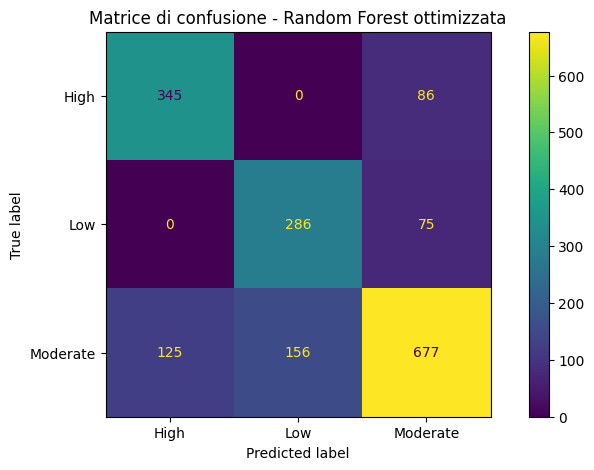

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, final_predictions)
plt.title(f"Matrice di confusione - {best_final_name}")
plt.show()

## 16. Analisi delle variabili più importanti

Per interpretare il modello, analizziamo l'importanza delle feature nel caso della Random Forest ottimizzata.  
Poiché le variabili categoriche sono state trasformate con one-hot encoding, ogni categoria diventa una feature distinta.

In [32]:
forest_best = forest_search.best_estimator_
forest_best.fit(X_train, y_train)

preprocessor = forest_best.named_steps["preprocessor"]
classifier = forest_best.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
53,cat__Family_Disease_History_None,0.209791
1,num__Mother_Age,0.184300
0,num__Father_Age,0.165586
52,cat__Family_Disease_History_Multiple,0.074903
50,cat__Family_Disease_History_Heart Disease,0.061289
3,num__Mother_Height_cm,0.033313
2,num__Father_Height_cm,0.032114
49,cat__Family_Disease_History_Diabetes,0.022086
51,cat__Family_Disease_History_Hypertension,0.021141
48,cat__Family_Disease_History_Asthma,0.016430


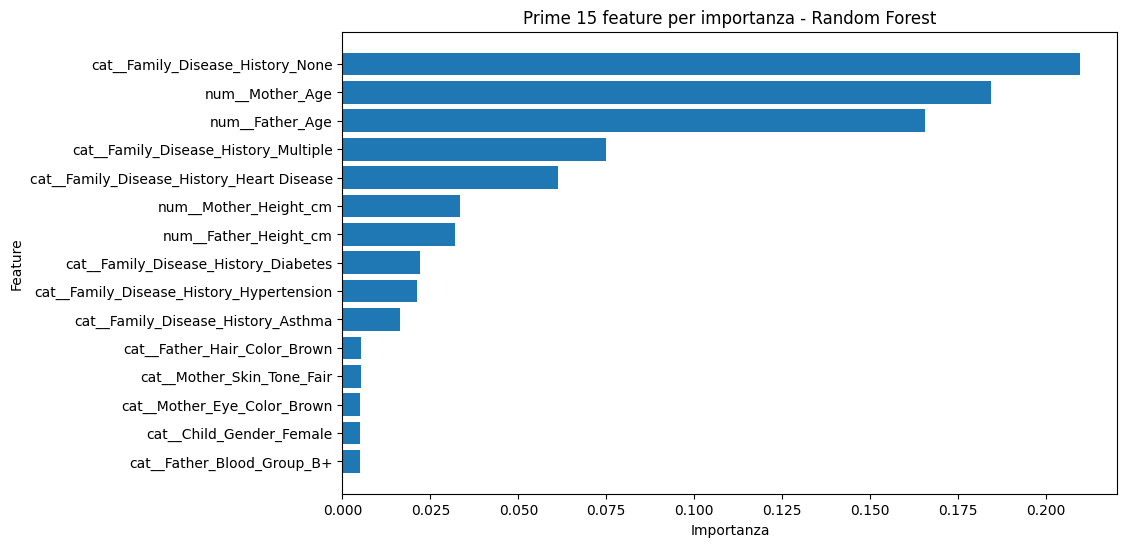

In [33]:
top_features = feature_importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Prime 15 feature per importanza - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.show()

Le feature più importanti sono legate soprattutto alla storia familiare di malattie. Questo risultato è coerente con l'obiettivo della predizione, perché la presenza o assenza di patologie familiari è un'informazione direttamente collegata al rischio di salute previsto.

## 17. Analisi di un albero decisionale

Per avere un modello più interpretabile, visualizziamo i primi livelli di un albero decisionale addestrato sugli stessi dati. Limitiamo la profondità per rendere leggibile il grafico.

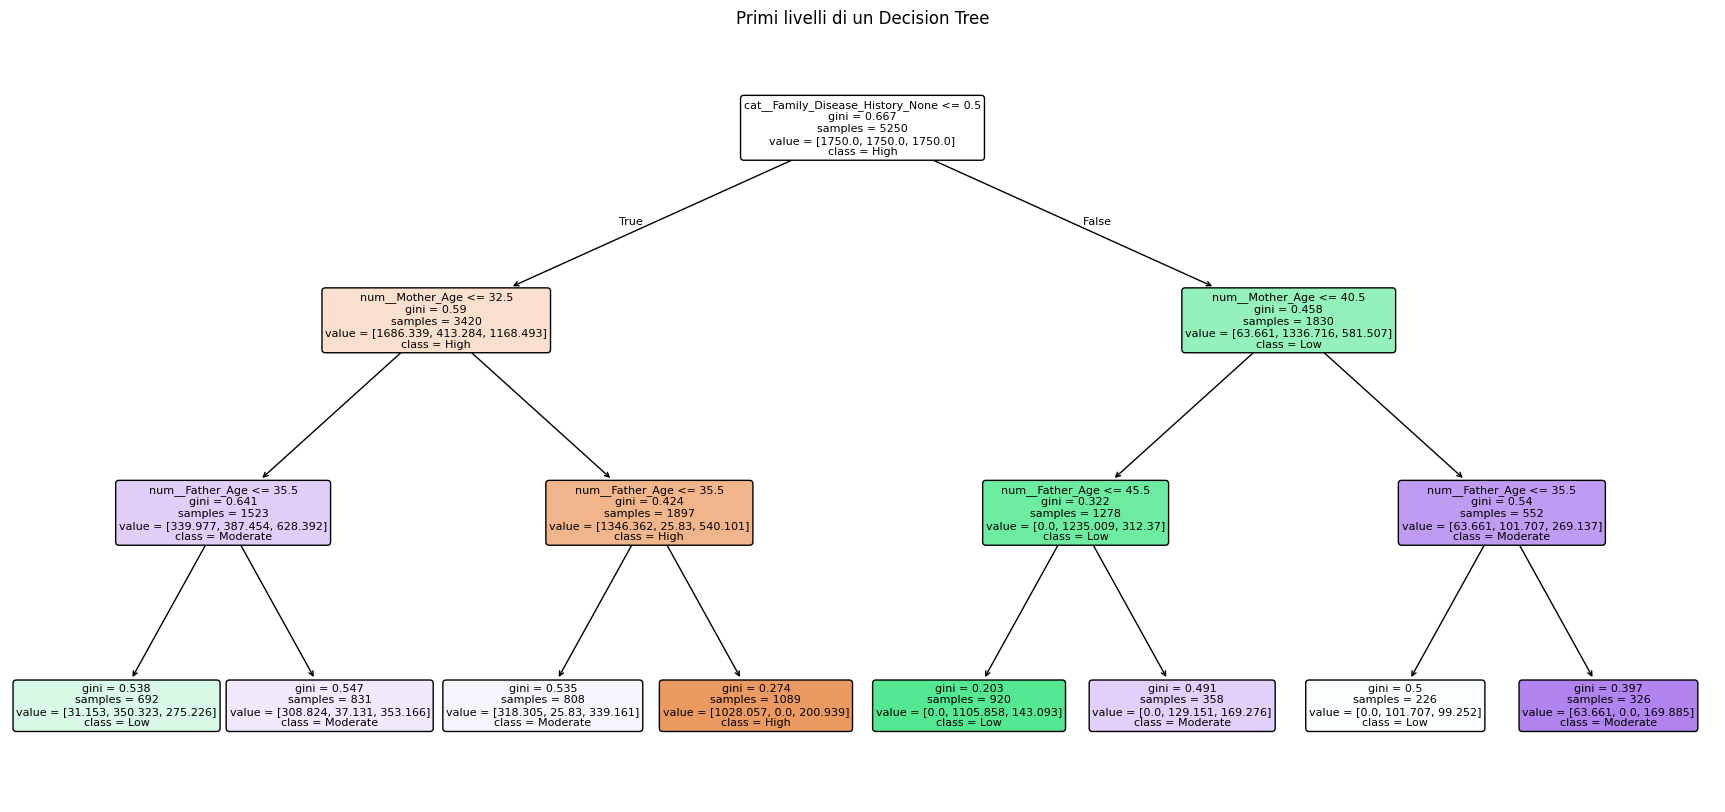

In [34]:
interpretable_tree = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, class_weight="balanced"))
])

interpretable_tree.fit(X_train, y_train)

feature_names_tree = interpretable_tree.named_steps["preprocessor"].get_feature_names_out()
class_names_tree = interpretable_tree.named_steps["classifier"].classes_

plt.figure(figsize=(22, 10))
plot_tree(
    interpretable_tree.named_steps["classifier"],
    feature_names=feature_names_tree,
    class_names=class_names_tree,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Primi livelli di un Decision Tree")
plt.show()

L'albero decisionale mostra in modo esplicito alcune regole usate dal modello. Anche in questo caso emergono variabili collegate alla storia familiare, confermando l'importanza di questa informazione.

## 18. Conclusioni

Il progetto ha affrontato un problema di **classificazione multiclasse** con l'obiettivo di prevedere il rischio di salute del figlio a partire dalle caratteristiche dei genitori.

Le principali operazioni svolte sono state:

- caricamento e pulizia del dataset;
- rimozione della variabile identificativa `Family_ID`;
- gestione dei valori mancanti in `Family_Disease_History`;
- esclusione delle colonne potenzialmente causa di leakage;
- analisi esplorativa delle variabili numeriche e categoriche;
- preparazione dei dati con one-hot encoding e standardizzazione;
- confronto tra più modelli di classificazione;
- ricerca degli iperparametri tramite Grid Search;
- analisi delle feature più importanti.

I risultati mostrano che i modelli addestrati superano nettamente la baseline. Tra i modelli provati, la Random Forest risulta particolarmente adatta perché riesce a sfruttare bene variabili categoriche e relazioni non lineari.

Dal punto di vista interpretativo, la variabile più rilevante è la storia familiare di malattie, coerentemente con il significato del target `Predicted_Health_Risk`.  
Come possibile sviluppo futuro, si potrebbero provare modelli più avanzati come Gradient Boosting, XGBoost o LightGBM, oppure eseguire una validazione più approfondita tramite nested cross validation.